# **Predicting Concrete Strength**


# Importing Libraries

In [373]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

# Loading & Viewing the data

In [374]:
concrete = pd.read_csv('concrete.csv')
concrete

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,141.3,212.0,0.0,203.5,0.0,971.8,748.5,28,29.89
1,168.9,42.2,124.3,158.3,10.8,1080.8,796.2,14,23.51
2,250.0,0.0,95.7,187.4,5.5,956.9,861.2,28,29.22
3,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.85
4,154.8,183.4,0.0,193.3,9.1,1047.4,696.7,28,18.29
...,...,...,...,...,...,...,...,...,...
1025,135.0,0.0,166.0,180.0,10.0,961.0,805.0,28,13.29
1026,531.3,0.0,0.0,141.8,28.2,852.1,893.7,3,41.30
1027,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1028,342.0,38.0,0.0,228.0,0.0,932.0,670.0,270,55.06


In [375]:
concrete.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cement        1030 non-null   float64
 1   slag          1030 non-null   float64
 2   ash           1030 non-null   float64
 3   water         1030 non-null   float64
 4   superplastic  1030 non-null   float64
 5   coarseagg     1030 non-null   float64
 6   fineagg       1030 non-null   float64
 7   age           1030 non-null   int64  
 8   strength      1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [376]:
concrete.describe()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


# Graphs

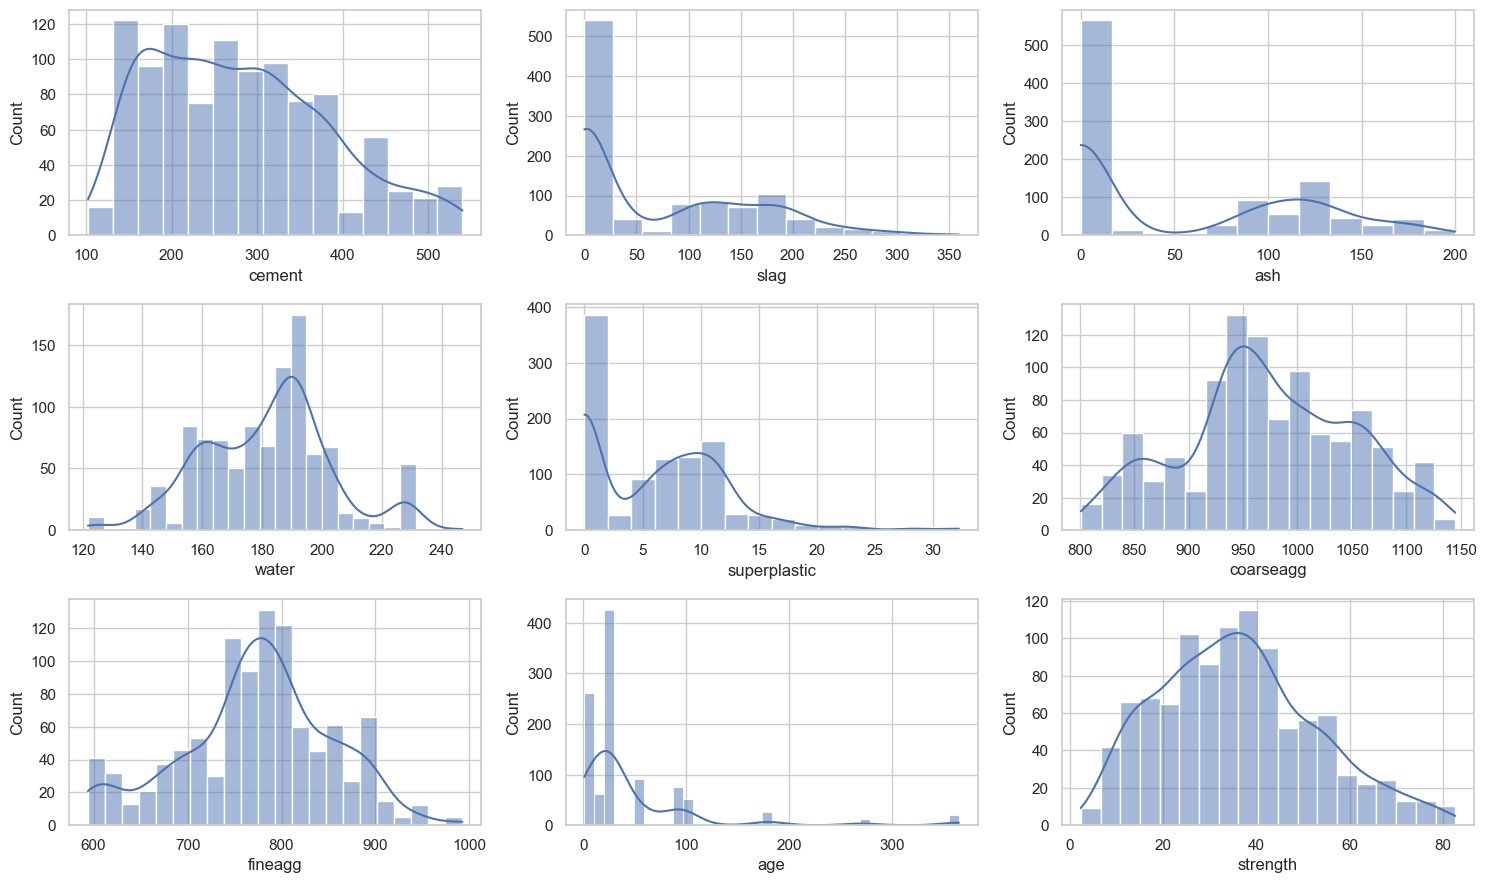

In [377]:
# grid
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(15,9))

# converting ax to 1D array
ax = ax.flatten()

columns = concrete.columns

i = 0
for col in columns:
    sns.histplot(data=concrete, x = col, ax=ax[i], kde=True)
    i += 1

plt.tight_layout()
plt.show()

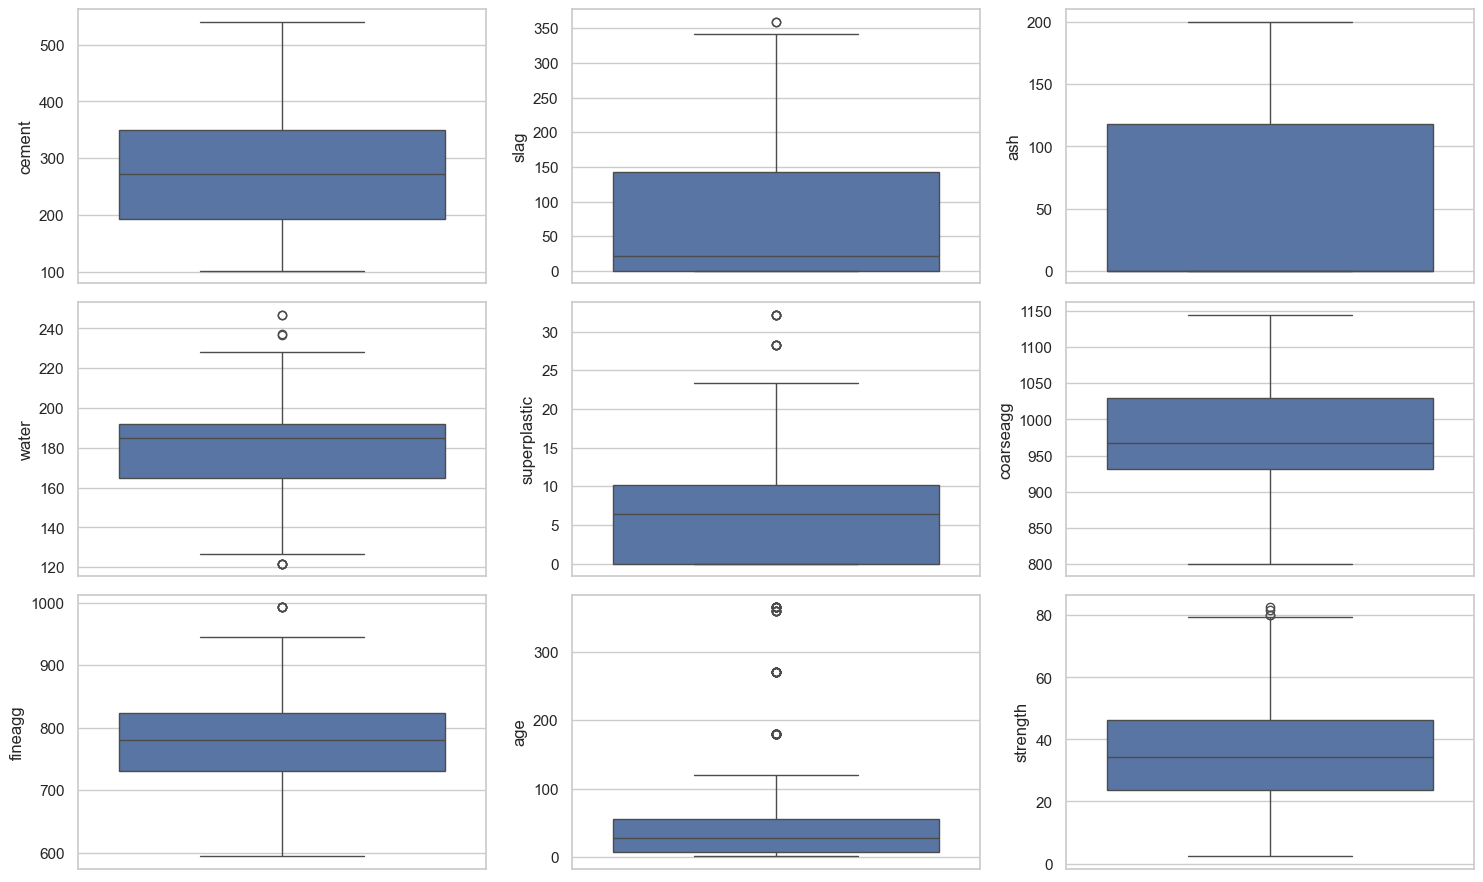

In [378]:
# grid
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(15,9))

# converting ax to 1D array
ax = ax.flatten()

columns = concrete.columns

i = 0
for col in columns:
    sns.boxplot(data=concrete, y = col, ax=ax[i])
    i += 1

plt.tight_layout()
plt.show()

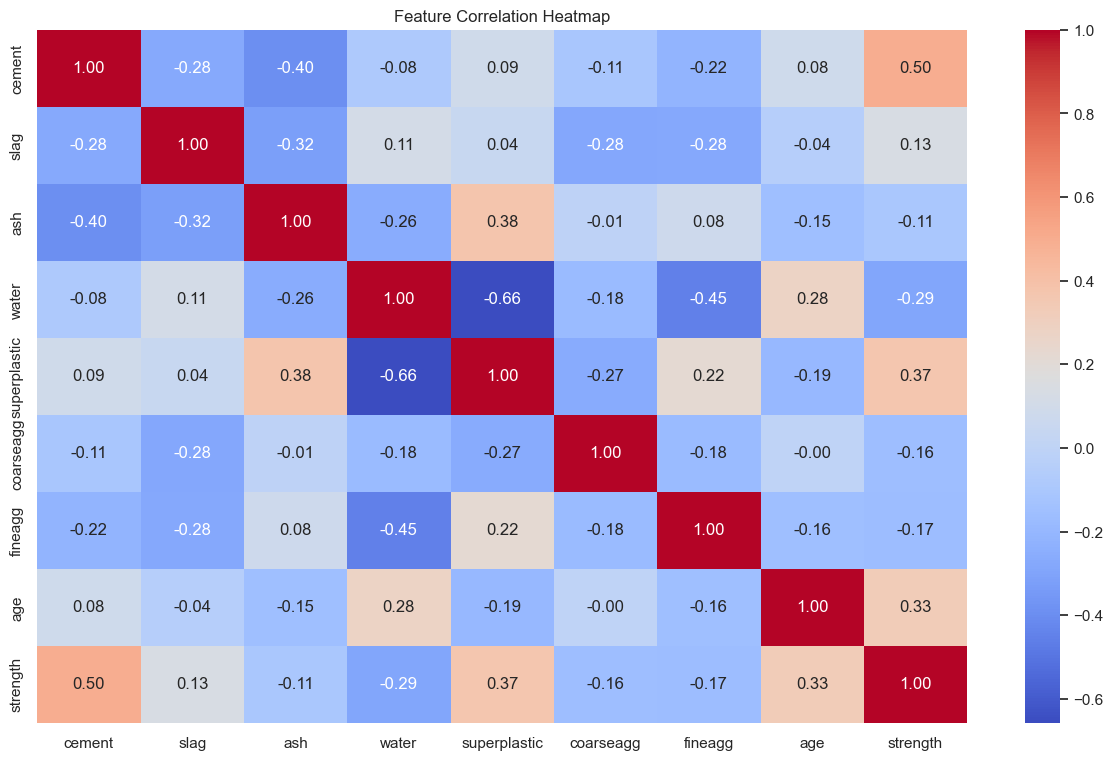

In [379]:
fig, ax = plt.subplots(figsize=(15,9))

corr_matrix = concrete.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', ax=ax)


ax.set_title('Feature Correlation Heatmap')
plt.show()

# Data Preprocessing

In [380]:
# Separate Features (X) and Target (y)
X = concrete.drop('strength', axis=1)
y = concrete['strength']

In [381]:
# The train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


In [382]:
# Feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# train the scaler model on training (not test) data
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Trying Standard Linear Regression

In [383]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred = lr_model.predict(X_test_scaled)

In [384]:
# Evaluating the model
from sklearn.metrics import r2_score, root_mean_squared_error

r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print('R2 Score: ', r2)
print('RMSE: ', rmse)

R2 Score:  0.5941085405855637
RMSE:  10.525561553940227


# Trying Polynomial Regression

In [385]:
from sklearn.preprocessing import PolynomialFeatures
poly_converter = PolynomialFeatures(degree=2, include_bias=False)
poly_converter.fit(X_train_scaled)

X_train_poly = poly_converter.transform(X_train_scaled)
X_test_poly = poly_converter.transform(X_test_scaled)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

y_pred_poly = poly_model.predict(X_test_poly)

In [386]:
# Evaluating the model
from sklearn.metrics import r2_score, root_mean_squared_error

r2 = r2_score(y_test, y_pred_poly)
rmse = root_mean_squared_error(y_test, y_pred_poly)

print('R2 Score: ', r2)
print('RMSE: ', rmse)

R2 Score:  0.7814529864422759
RMSE:  7.723475209273672


# Optimising the polynomial regression model to find the best Hyperparameter (degree)

In [387]:
from sklearn.pipeline import Pipeline

pipe = Pipeline(steps=[
    ('poly', PolynomialFeatures(include_bias=False)), 
    ('model', LinearRegression())
])

In [388]:
# optimising using grid search CV
from sklearn.model_selection import GridSearchCV

param_grid = {
    'poly__degree':[1,2,3,4]
}

grid_search = GridSearchCV(estimator = pipe, 
                           param_grid=param_grid,
                           cv=5,
                           scoring='r2',
                           n_jobs=-1)

grid_search.fit(X_train_scaled, y_train)

best_para = grid_search.best_params_
best_score = grid_search.best_score_

print(best_para, best_score)

{'poly__degree': 3} 0.8120620480685037


In [389]:
# Best model
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred_best)
rmse = root_mean_squared_error(y_test, y_pred_best)

print('R2 Score: ', r2)
print('RMSE: ', rmse)

R2 Score:  0.9004240548639071
RMSE:  5.21335786261136
